# Clase 02: Introducción al uso de python para la manipulación de imágenes satelitales. 

Lo que veremos en esta notebook:

- [x] Lectura de una imagen satelital en formato Geotiff y en formato HDF
- [x] Extracción de los metadatos principales de una imagen satelital
- [x] Geolocalización de la imagen: El concepto del _transform_ o transformación.
- [x] Lectura de la imagen como matriz de datos de Numpy
- [x] Aspectos a tener en cuenta sobre la visualización y realce (píxeles sin datos)

**Datos con los que vamos a trabajar en esta Notebook**:

- Archivo Geotiff `SPOT_20170806_PAN.tif`, disponible para descargar en este [enlace](https://drive.google.com/file/d/1MN_qBLE_1wMBCjvIb9jrSBkxa7iRimJD/view?usp=sharing).
- Archivo GeoTiff `Class_IMG_CLF_DT_13.tif` disponible para descargar en este [enlace](https://drive.google.com/file/d/1joFxHVB0kscNl0lSCMyKhZ9OFNedfiKm/view?usp=sharing).
- Archivo en formato HDF `MOD09A1.A2000049.h11v08.006.2015136143404.hdf` representando una adquisición del instrumento MODIS, disponible para descargar en este [enlace](https://drive.google.com/file/d/13nmBT7L0yf10paTHQz1R12xSNYpvXXAj/view?usp=sharing)

Ponelos a todos en tu carpeta `data` para que funcionen los  _path_ empleados en esta Notebook.

# 1. Imágenes satelitales
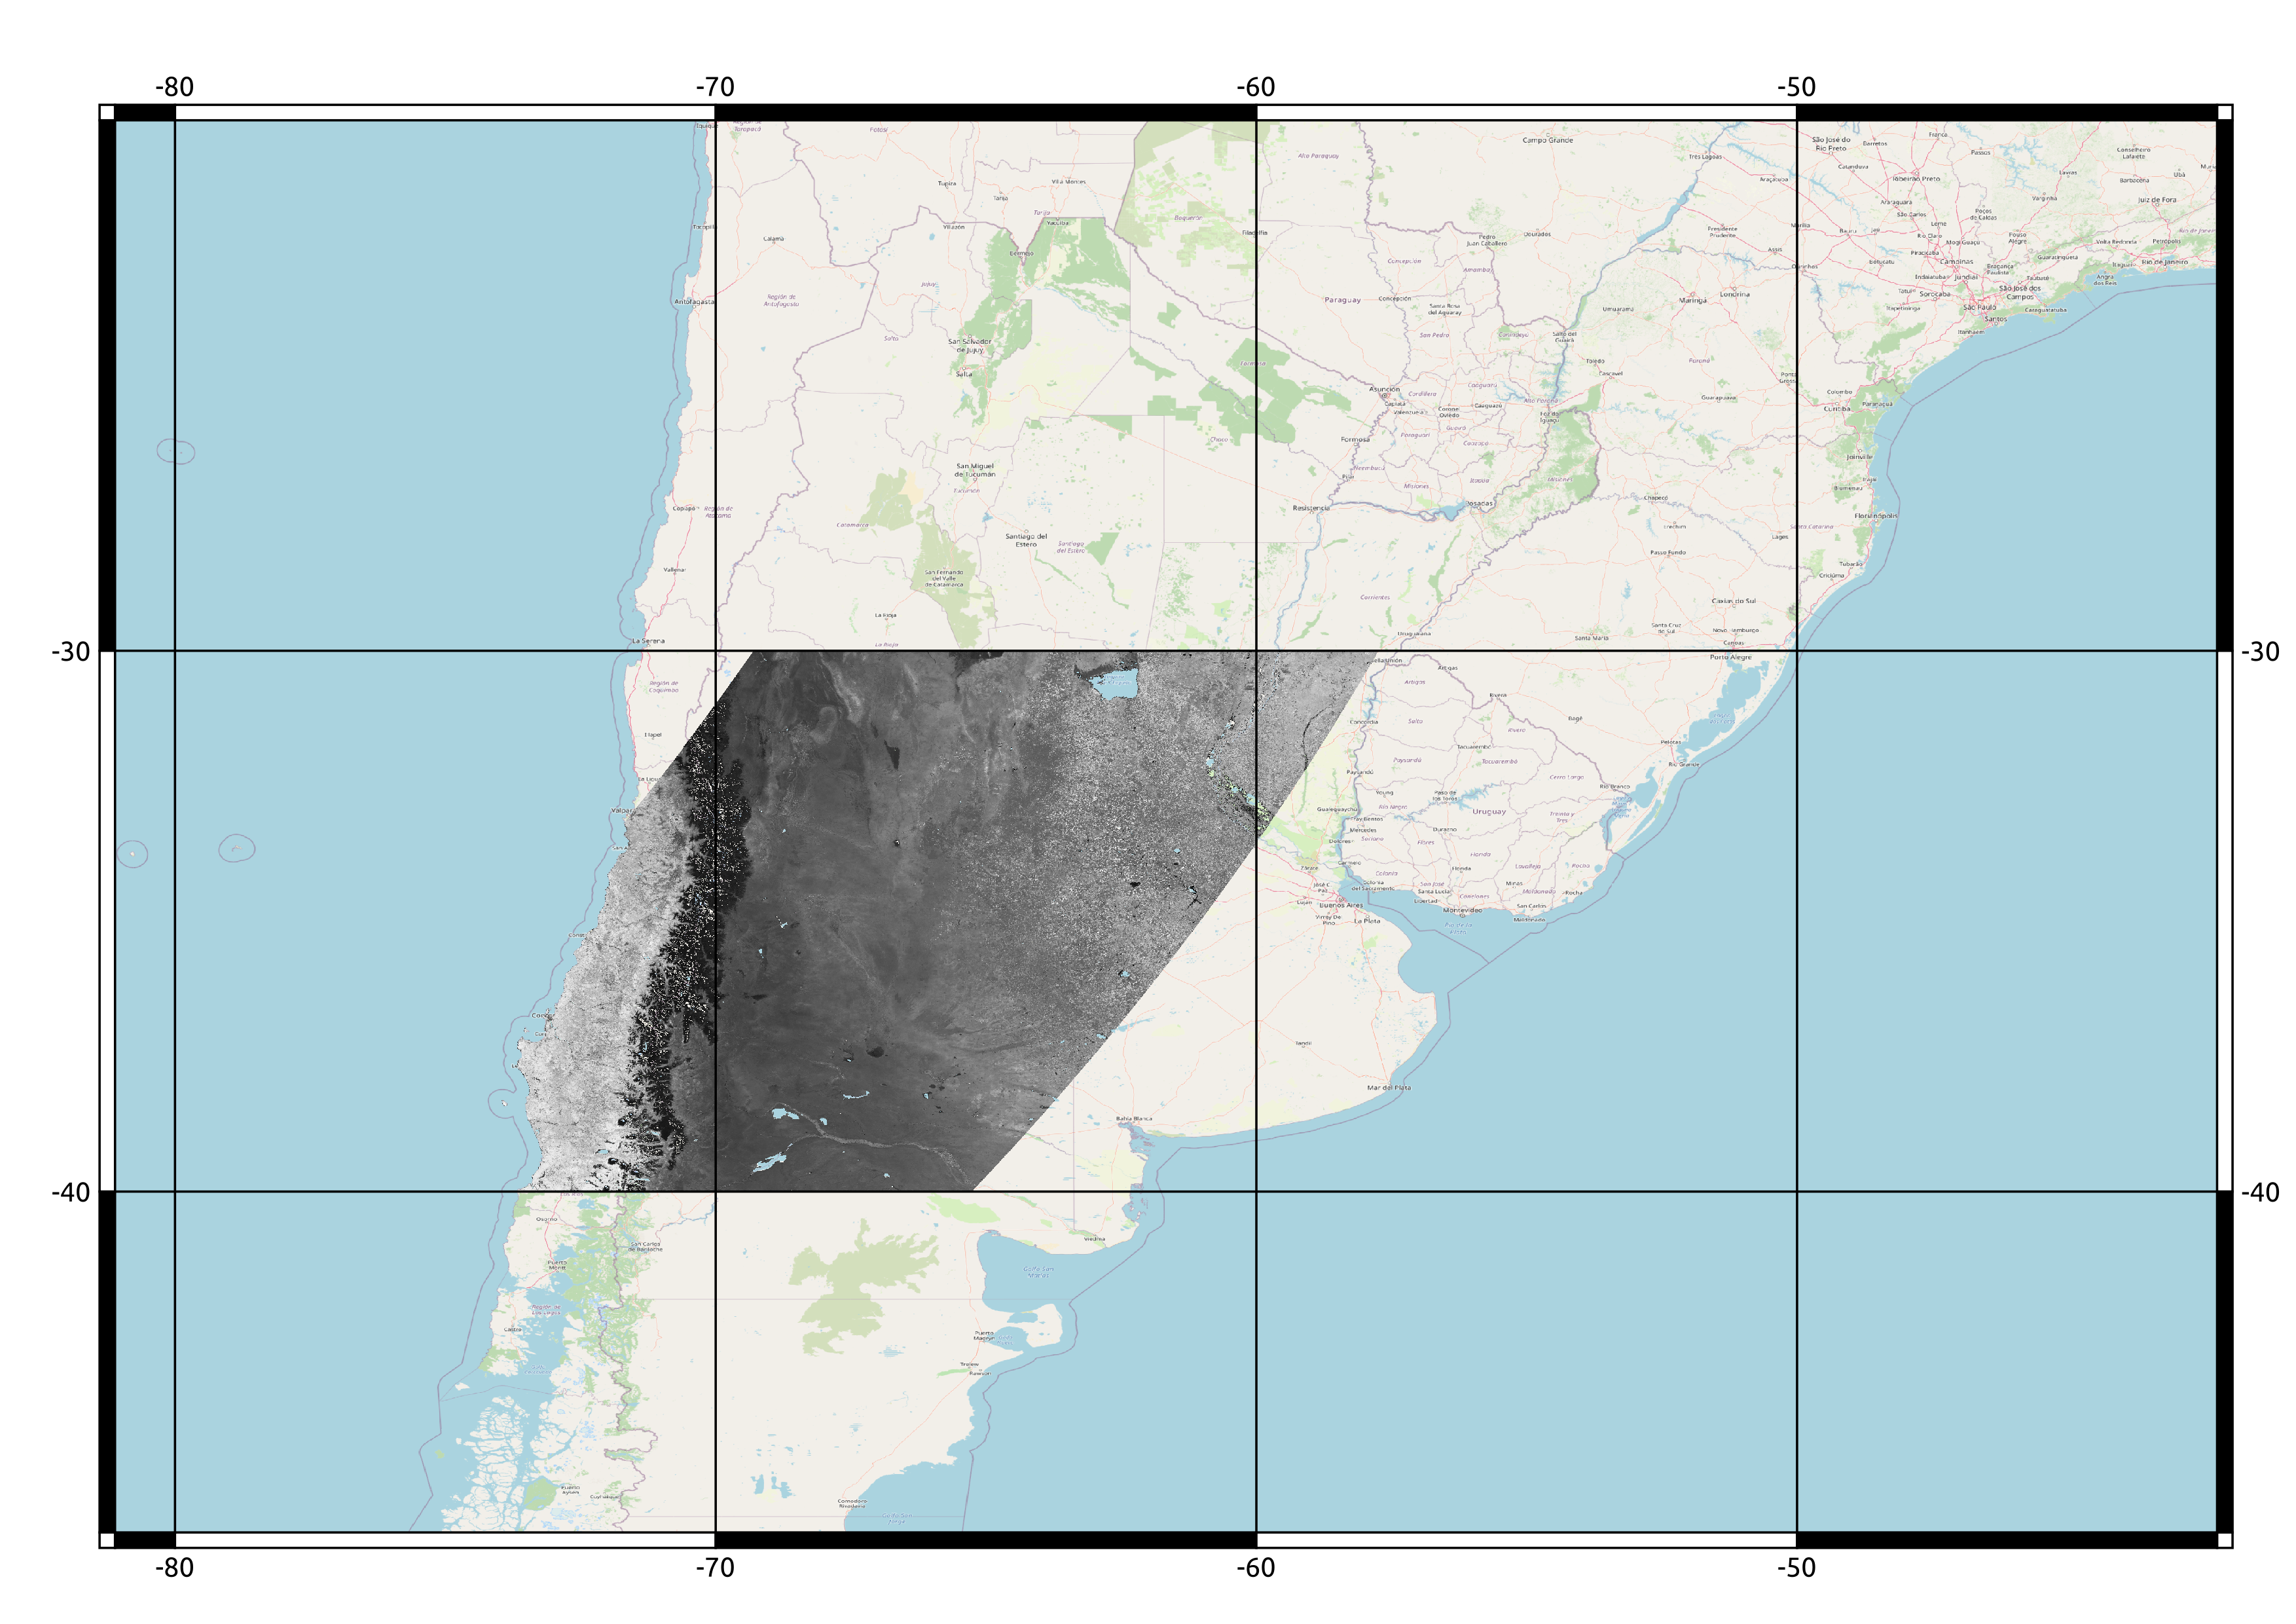

### ¿Qué información podremos extraer de una imagen satelital?
### ¿Cómo podemos acceder a dicha información?

# 2. Librería Rasterio

Para leer imágenes georreferenciadas podemos usar principalmente dos librerías: `GDAL` o `Rasterio`. `GDAL` (Geospatial Data Abstraction Library) es una biblioteca de código abierto ampliamente utilizada para el procesamiento y manipulación de datos geoespaciales. En Python, GDAL se accede a través del paquete osgeo.gdal, que permite leer, escribir y convertir formatos raster y vectoriales. Se parece más a una librería clásica de `C` con lo cual implica trabajar o progamar más en bajo nivel. `Rasterio` viene a ser la adaptación de GDAL para las convenciones de Python: Usa esta librería como base, pero permite al usuario trabajar a más alto nivel. Ofrece algunas ventajas en cuanto a funcionalidades que ahorran mucho trabajo al usuario, y usaremos algunas de estas en esta clase.


```python
import rasterio
```

In [1]:
import rasterio

## 2.1. Información básica de un ráster

Carguemos las siguientes librerías antes de proceder a la lectura del raster:

```python
import matplotlib.pyplot as plt
import numpy as np
```

In [3]:
import matplotlib.pyplot as plt
import numpy as np

A continuación vamos a leer la imagen SPOT pancromática de la Clase 01 como objeto de `rasterio`:

```python
ds = rasterio.open('data/SPOT_20170806_PAN.tif')
print(ds)
```

In [10]:
ds = rasterio.open('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/SPOT_20170806_PAN.tif')
print(ds)

<open DatasetReader name='https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/SPOT_20170806_PAN.tif' mode='r'>


Existen algunos comandos para acceder a la información básica de nuestros datos ráster también llamados _metadatos_. Estos proporcionan información acerca de las características de cada uno de nuestros recursos. Veamos cómo consultar esa información con Rasterio: 

```python
# Obtener la lista de archivos del dataset
print(ds.files)
```

In [6]:
# Obtener la lista de archivos del dataset
print(ds.files)

['/vsicurl/https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/SPOT_20170806_PAN.tif']


```python
# Consulta la cantidad de bandas, el tamaño en columnas y en filas:
print("Número de bandas:", ds.count)
print("Número de columnas:", ds.width)
print("Número de filas:", ds.height)
```

In [7]:
# Consulta la cantidad de bandas, el tamaño en columnas y en filas:
print("Número de bandas:", ds.count)
print("Número de columnas:", ds.width)
print("Número de filas:", ds.height)

Número de bandas: 1
Número de columnas: 7204
Número de filas: 3956


Podemos adicionalmente obtener datos acerca del formato de la imagen:

```python
# Obtener información acerca del formato de la imagen
print("Formato:", ds.driver)
```

In [8]:
# Obtener información acerca del formato de la imagen
print("Formato:", ds.driver)

Formato: GTiff


El `driver` o formato es algo que necesitamos para guardar nuestras imágenes de salida. Es posible consultar todos los `drivers` o formatos que maneja `Rasterio` usando el siguiente comando:

```python
with rasterio.Env() as env:
    for driver, descripcion in sorted(env.drivers().items()):
        print(f"{driver:20} {descripcion}")
```

In [ ]:
with rasterio.Env() as env:
    for driver, descripcion in sorted(env.drivers().items()):
        print(f"{driver:20} {descripcion}")

En general, `Rasterio` maneja o hereda los mismos Drivers que permite usar `GDAL`. Más información acerca de los formatos disponibles la encontrarán en el siguiente [enlace](https://gdal.org/drivers/raster/index.html).

Otra información importante corresponde al sistema de referencia de coordenadas (SRC) de la imagen. Esto nos indica en qué proyección y qué unidades de mapa estamos trabajando. 

Cuando trabajamos con más de una imagen, deberíamos asegurarnos que estas se encuentren en el mismo sistema de referencia, así como el mísmo tamaño de píxel, garantizando la correspondencia entre los datos de la matríz. En la siguiente celda podemos ver cómo se consulta el Sistema de referencia de la imagen, tanto a través de su código [EPSG](https://epsg.io/), como en su forma extendida, como _Well-Known-Text_ ([WKT](https://es.wikipedia.org/wiki/Well_Known_Text)).

```python
# Información de la proyección (código EPSG)
print("Información acerca de la proyección de la capa:\n")
print(ds.crs, "\n")

# Información extendida (Well-Known-Text)
print("Formato WKT:", ds.crs.to_wkt())
```

In [9]:
# Información de la proyección (código EPSG)
print("Información acerca de la proyección de la capa:\n")
print(ds.crs, "\n")

# Información extendida (Well-Known-Text)
print("Formato WKT:", ds.crs.to_wkt())

Información acerca de la proyección de la capa:

EPSG:32720 

Formato WKT: PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]


O de manera inversa, podemos definir la proyección a partir de un código EPSG conocido:
```python
from rasterio.crs import CRS

# Crear proyección a partir de código EPSG
crs = CRS.from_epsg(32720)
print(crs)
```

In [11]:
from rasterio.crs import CRS

# Crear proyección a partir de código EPSG
crs = CRS.from_epsg(32720)
print(crs)

EPSG:32720


## 2.2. Geotransformación o _Transform_

En Rasterio, la georreferenciación de una imagen se almacena en el atributo `transform`, que tiene estructura de una matriz o transformación afín. Esta transformación permite convertir las coordenadas de un píxel (columna, fila) en coordenadas reales del mapa (x, y).

Matemáticamente, la transformación se representa de manera matricial:

$$
\underbrace{
\begin{bmatrix}
a & b & c \\
d & e & f \\
0 & 0 & 1
\end{bmatrix}}_{3\times3}
\;
\underbrace{
\begin{bmatrix}
\text{col} \\
\text{fila} \\
1
\end{bmatrix}}_{3\times1}
\mathrel{=}
\underbrace{
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}}_{3\times1}
$$


Los seis parámetros importantes de esta matriz son:

- **a**: tamaño del píxel en la dirección Este-Oeste (ancho del píxel).
- **b**: rotación o inclinación de las filas (normalmente 0).
- **c**: coordenada **x** de la esquina superior izquierda del píxel superior izquierdo.
- **d**: rotación o inclinación de las columnas (normalmente 0).
- **e**: tamaño del píxel en la dirección Norte-Sur (normalmente negativo si el norte está hacia arriba).
- **f**: coordenada **y** de la esquina superior izquierda del píxel superior izquierdo.

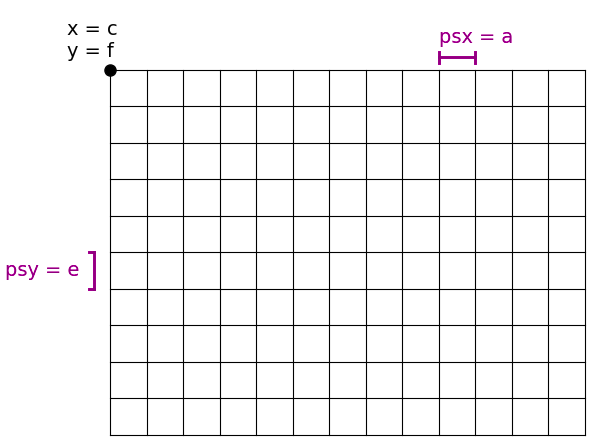

**¿Qué quiere decir todo esto esto?** Que con estos parámetros podemos calcular las coordenadas X-Y para cualquier píxel de la imagen:

$$
X_{\mathrm{geo}} = a \cdot \text{col} + b \cdot \text{fila} + c
$$

$$
Y_{\mathrm{geo}} = d \cdot \text{col} + e \cdot \text{fila} + f
$$

Para obtener más información acerca del módulo Trasnform de Rasterio, ir al siguiente [enlace](https://rasterio.readthedocs.io/en/latest/api/rasterio.transform.html)

El transform de la imagen se obtiene de la siguiente manera:

```python
transform = ds.transform
print(transform)
```

In [12]:
transform = ds.transform
print(transform)

| 1.50, 0.00, 388866.00|
| 0.00,-1.50, 6528056.00|
| 0.00, 0.00, 1.00|


Veamos cómo obtener la coordenada central del píxel (200, 300) de la imagen cargada anteriormente a partir de su `transform`:

```python
# Píxel de interés (fila, columna)
p_y = 200
p_x = 300

# Parámetros de la transformación afín
a = transform.a
b = transform.b
c = transform.c
d = transform.d
e = transform.e
f = transform.f

# Coordenadas de la esquina superior izquierda del píxel
coord_x = a * p_x + b * p_y + c
coord_y = d * p_x + e * p_y + f

print(f'Coordenadas x, y, esquina superior izquierda del píxel ({p_y}, {p_x}):')
print(f'({coord_x:.3f}, {coord_y:.3f})')

# Coordenadas del centro del píxel
print(f'Coordenadas x, y, centro del píxel ({p_y}, {p_x}):')
print(f'({coord_x + a/2:.3f}, {coord_y + e/2:.3f})')
```

In [13]:
# Píxel de interés (fila, columna)
p_y = 200
p_x = 300

# Parámetros de la transformación afín
a = transform.a
b = transform.b
c = transform.c
d = transform.d
e = transform.e
f = transform.f

# Coordenadas de la esquina superior izquierda del píxel
coord_x = a * p_x + b * p_y + c
coord_y = d * p_x + e * p_y + f

print(f'Coordenadas x, y, esquina superior izquierda del píxel ({p_y}, {p_x}):')
print(f'({coord_x:.3f}, {coord_y:.3f})')

# Coordenadas del centro del píxel
print(f'Coordenadas x, y, centro del píxel ({p_y}, {p_x}):')
print(f'({coord_x + a/2:.3f}, {coord_y + e/2:.3f})')

Coordenadas x, y, esquina superior izquierda del píxel (200, 300):
(389316.000, 6527756.000)
Coordenadas x, y, centro del píxel (200, 300):
(389316.750, 6527755.250)


No obstante, `Rasterio` ya tiene funciones optimizadas para hacer estos cálculos de manera más automática para el usuario.

```python
coord_x, coord_y = ds.xy(p_y, p_x)

print(f'Coordenadas x, y, centro del píxel ({p_y}, {p_x}):')
print(f'({coord_x:.3f}, {coord_y:.3f})')

coord_x, coord_y = ds.xy(p_y, p_x, offset='ul')

print(f'Coordenadas x, y, esquina superior izquierda del píxel ({p_y}, {p_x}):')
print(f'({coord_x:.3f}, {coord_y:.3f})')
```

De manera inversa, se puee obtener también la columna correspondiente a un par (x,y) utilizando `ds.index()`:

```python
# Coordenadas del centro del píxel
coord_x, coord_y = ds.xy(p_y, p_x)

# Obtener fila y columna a partir de las coordenadas
row, col = ds.index(coord_x, coord_y)

print(f'Índices del píxel que contiene las coordenadas ({coord_x:.3f}, {coord_y:.3f}):')
print(f'(fila={row}, columna={col})')
```

### Ejercicio - ¿Para qué más podemos usar el transform?

Supongamos que tenemos el siguiente mapa clasificado, guardado como archivo GeoTiff. El mismo está en `data/Class_IMG_CLF_DT_13.tif`.


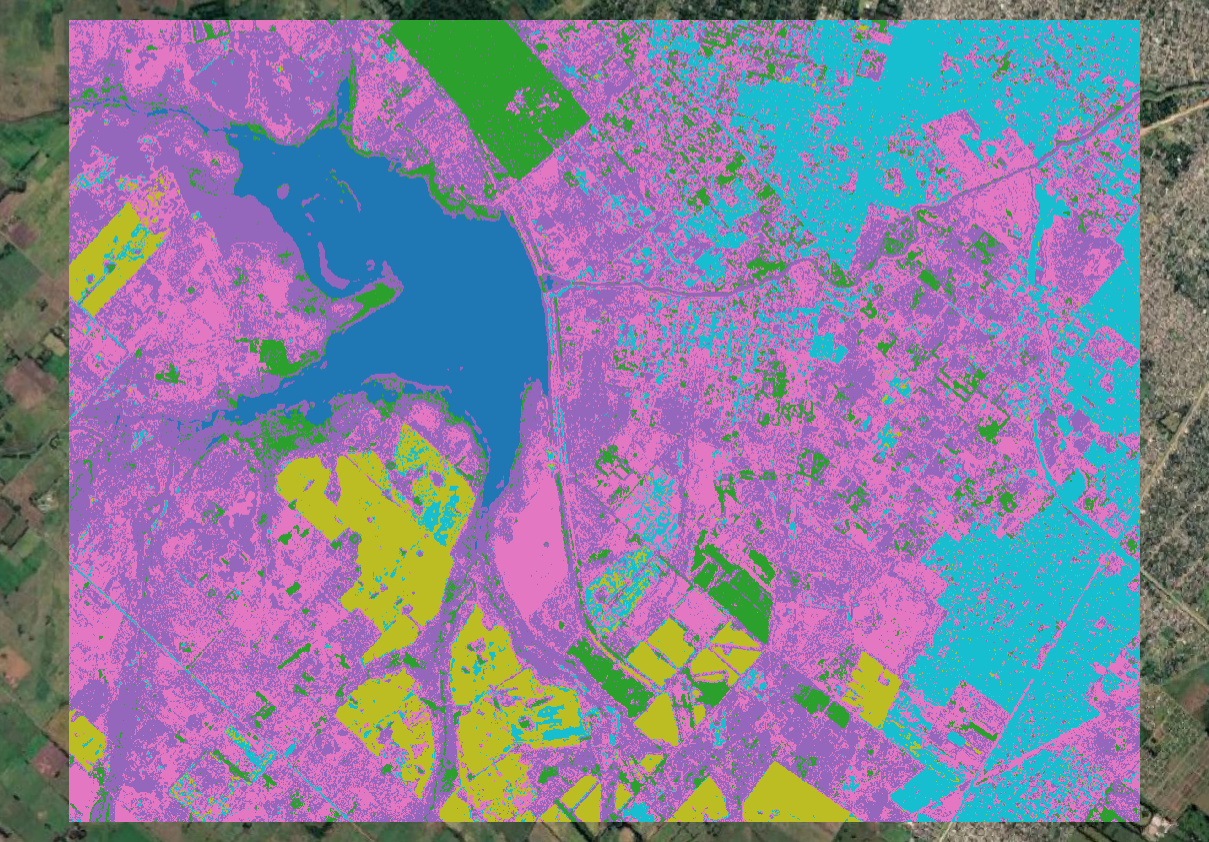

¿Cómo se te ocurriría usar el `transform` y otras herramientas para averiguar cuánta superficie ocupa cada clase?

In [4]:
# Leo la imagen de clasificación
img_clas = rasterio.open('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/Class_IMG_CLF_DT_13.tif')

In [5]:
# Printeo el CRS
print(f'CRS:{img_clas.crs}')

# Printeo parámetros
print(f'a: {img_clas.transform.a}; e: {img_clas.transform.e}')


CRS:EPSG:32721
a: 10.0; e: -10.0


In [6]:
# Computo área
area_px = img_clas.transform.a * img_clas.transform.e * (-1)

# Printeo área
print(f'Área [m2]: {area_px}')

Área [m2]: 100.0


In [7]:
# Abro los datos como numpy array
datos_clas =img_clas.read()[0]

# Obtengo valores únicos
clas_unique = np.unique(datos_clas)
print(clas_unique) # clases únicas de pxs

[0 1 2 3 4 5]


In [8]:
# Calculo el área total de las clases en m2
for i, c in enumerate(clas_unique):
    print(f'Clase: {c}')
    mascara = (datos_clas == c)
    area_clase =  np.sum(mascara*1)*area_px
    print(f'Area clase {c} [m2]: {area_clase}')

Clase: 0
Area clase 0 [m2]: 7917000.0
Clase: 1
Area clase 1 [m2]: 9274000.0
Clase: 2
Area clase 2 [m2]: 38922700.0
Clase: 3
Area clase 3 [m2]: 36926200.0
Clase: 4
Area clase 4 [m2]: 8792300.0
Clase: 5
Area clase 5 [m2]: 18849700.0


In [9]:
# Otra forma
areas_clases = np.unique(datos_clas, return_counts = True)

# Printeo resultados
print(f'Area clases [m2]: {areas_clases[1]*area_px}')

Area clases [m2]: [ 7917000.  9274000. 38922700. 36926200.  8792300. 18849700.]


<BarContainer object of 6 artists>

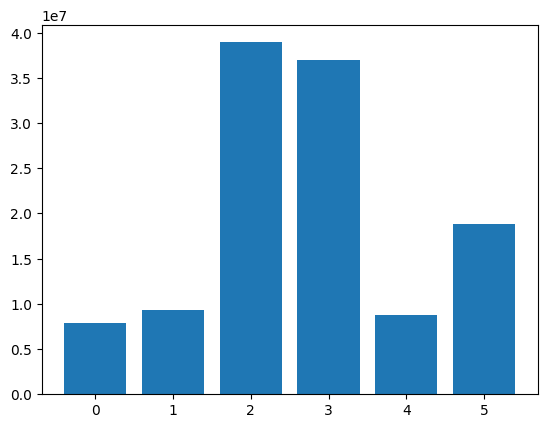

In [11]:
plt.bar(areas_clases[0], 
         areas_clases[1]*area_px)

## 2.3. El método Read de Rasterio

Recordemos que las imágenes son matrices de datos donde, en el caso de las imágenes satelitales ópticos, estos corresponden a valores de radiación medidos por el sensor. Vamos ahora a extraer esos valores, para lo cual, ejecutaremos el siguiente comando:

```python
sds = ds.read()
```

#### Responder:

- ¿Qué tipo de objeto es sds?

- ¿Cuantas dimensiones tiene el objeto sds? Cuál corresponde a las filas y cuál a las columnas?

- ¿Qué tipo de datos tiene el objeto sds?

El método ***read()*** brinda diferentes opciones para acceder a los valores de la matriz. Si vamos a la ayuda del mismo, veremos la definición del método y sus posibles opciones. Las más importantes son:

>**indexes** = Banda o lista de bandas a leer. Por defecto se leen todas las bandas del dataset. Si se especifica alguna, tener en cuenta que se lee desde el índice 1, no 0 como en el resto de la indezación que usa Python\
**window** = Ventana de lectura, definida mediante `rasterio.windows.Window(col_off, row_off, width, height)`. Permite extraer un recorte de la imagen. Por defecto se lee la imagen completa.\
**out_shape** = Dimensiones del array de salida `(bandas, filas, columnas)` o `(filas, columnas)` para una única banda. Si difiere del tamaño de la ventana, los datos serán remuestreados.\
**resampling** = Método de remuestreo utilizado cuando se especifica `out_shape`. Algunos métodos disponibles son `nearest`, `bilinear`, `cubic`, `average`, entre otros. Por defecto utiliza `nearest`.\
**out_dtype** = Tipo de dato del array de salida (`uint8`, `int16`, `float32`, etc.). Si no se especifica, se utiliza el tipo de dato original del raster.

Para profundizar en este tema pueden ir al siguiente [enlace](https://rasterio.readthedocs.io/en/stable/topics/reading.html).

Cuando no pasamos ningún valor a `indexes`, se lee la imagen con todas las bandas disponibles, resultando en 3 dimensiones `(bandas, filas, columnas)`. En ese caso, cuando queremos hacer el ploteo con `imshow` podemos usar la indexación de `Numpy` para quedarnos un un array 2D:

```python
from rasterio.windows import Window

# Leeremos todas las bandas, en este caso solo 1
sds2 = ds.read(window=Window(100, 100, 1500, 1500))
print(sds2.shape)

# Plotear, hacemos sds2[0] para que sea un array 2D
fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(sds2[0], cmap='Greys_r')
ax.set_title('Subset')
plt.show()
```

(1, 1500, 1500)


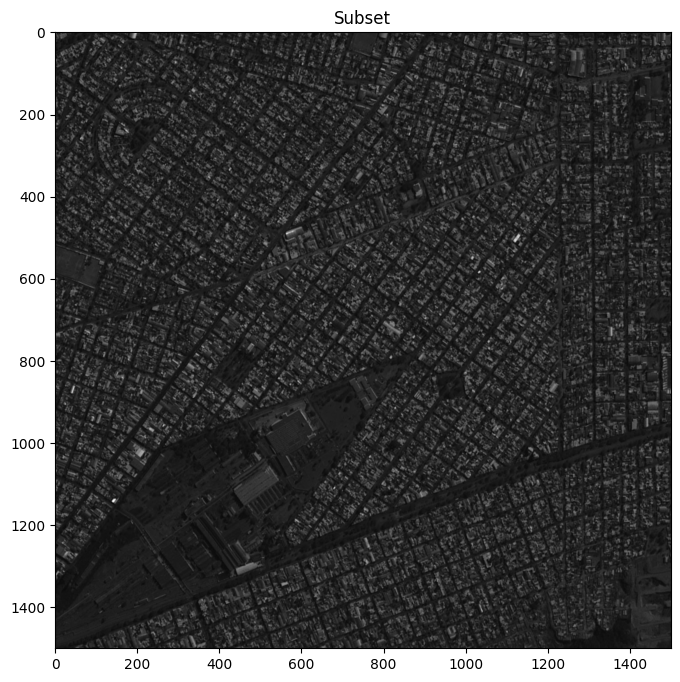

In [12]:
from rasterio.windows import Window

# Leeremos todas las bandas, en este caso solo 1
sds2 = ds.read(window=Window(100, 100, 1500, 1500))
print(sds2.shape)

# Plotear, hacemos sds2[0] para que sea un array 2D
fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(sds2[0], cmap='Greys_r')
ax.set_title('Subset')
plt.show()

### Ejercicio:

1. A partir de las siguientes coordenadas:
 ```python
 ul_x, ul_y = 389015.794, 6527907.484 # Esquina superior izquierda
 lr_x, lr_y = 391265.904, 6525657.498 # Esquina inferior derecha
 ```
 Calcule los parámetros col_off, row_off, width, height para leer un recorte de la SPOT a partir de dichas coordenadas. Cargue el array de la imagen siguiendo la estructura que se muestra a continuación y visualícela:
```python
sds_subset = ds.read(window=Window(col_off, row_off, width, height))

fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(sds_subset[0], cmap='Greys_r')
ax.set_title('Subset')
plt.show()
```
 Recuerde que los parámetros de entrada deben ser números enteros.
 
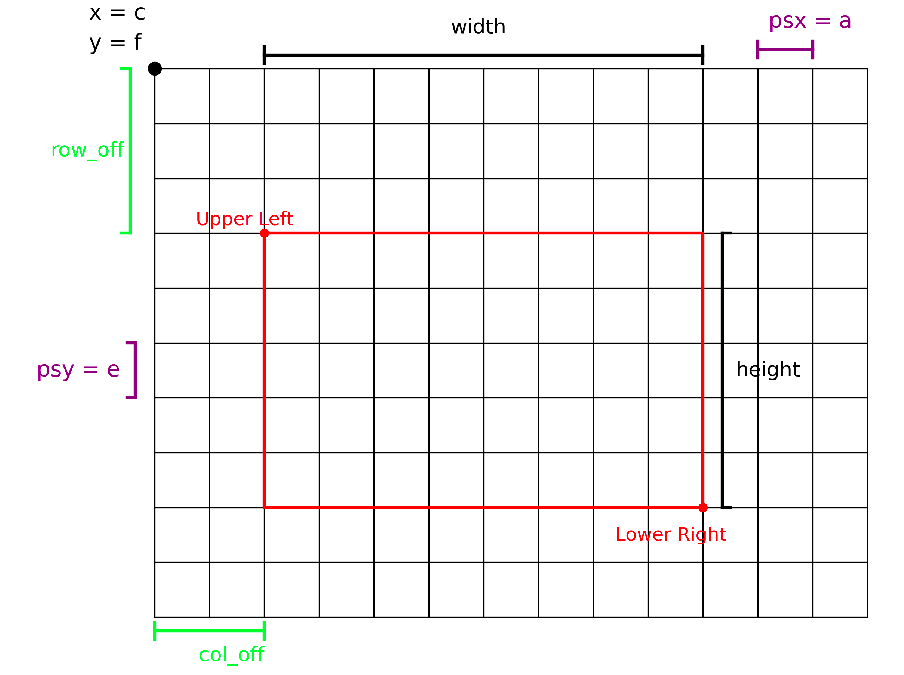

Puede usar `ds.index()` para determinar los píxeles de las esquinas del recorte, y así determinar el tamaño de la ventana, y su corrimiento respecto al origen.

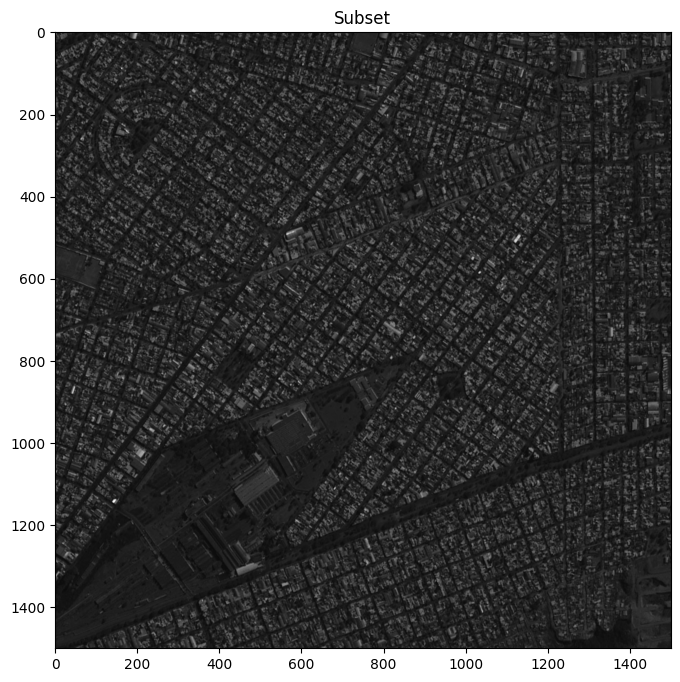

In [ ]:
ul_x, ul_y = 389015.794, 6527907.484 # Esquina superior izquierda
lr_x, lr_y = 391265.904, 6525657.498 # Esquina inferior derecha

# Calcule los parámetros col_off, row_off, width, height para leer un recorte de la SPOT a partir de dichas coordenadas. 
col_off, row_off = ds.index(ul_x, ul_y)
ps_x = ds.transform.a
ps_y = ds.transform.e*(-1)
width = round((lr_x-ul_x)/ps_x)
height = round((ul_y-lr_y)/ps_y)

# Cargo el array de la imagen siguiendo la estructura que y se muestra a continuación:
sds_subset2 = ds.read(window=Window(col_off, row_off, width, height))

fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(sds_subset2[0], cmap='Greys_r')
ax.set_title('Subset')
plt.show()

# 3. Visualización de la imagen - Tratamiento de los píxeles sin datos

Retomaremos aquí el uso de la función `scale()` que diseñamos luego de la primera clase para plotear bandas de otros datos satelitales que vienen afectados por zonas sin datos. De paso, aprenderemos a ver cómo podemos encontrar cuál es ese valor de `nodata`. Primero la definimos aquí para tener todos la misma base, mostrando una implementación que usa los percentiles para estirar la imagen:

```python
import numpy as np

def escalar_imagen(imagen, p):
  # Calcular los percentiles p y 100-p
  valor_min = np.percentile(imagen, p)
  valor_max = np.percentile(imagen, 100-p)

  # Truncar la imagen al rango [p1, p99]
  ecualizada = np.clip(imagen, valor_min, valor_max)

  # Normalizar la imagen al rango 0-255.
  ecualizada = (ecualizada - valor_min) / (valor_max - valor_min) * 255

  # Convertir la imagen ecualizada a entero de 8 bits
  ecualizada = np.uint8(ecualizada)

  # Retornar la imagen ecualizada
  return ecualizada
```

In [17]:
def escalar_imagen(imagen, p):
  # Calcular los percentiles p y 100-p
  valor_min = np.percentile(imagen, p)
  valor_max = np.percentile(imagen, 100-p)

  # Truncar la imagen al rango [p1, p99]
  ecualizada = np.clip(imagen, valor_min, valor_max)

  # Normalizar la imagen al rango 0-255.
  ecualizada = (ecualizada - valor_min) / (valor_max - valor_min) * 255

  # Convertir la imagen ecualizada a entero de 8 bits
  ecualizada = np.uint8(ecualizada)

  # Retornar la imagen ecualizada
  return ecualizada

La escena con la que trabajaremos aquí es una adquisición del instrumento MODIS (Moderate-Resolution Imaging Spectroradiometer) que viene en formato HDF (Hierarchical Data Format). Rasterio es capaz de abrirlo al igual que hicimos con el Geotiff. Sin embargo, la estructura de un HDF es más compleja. Adentro de un HDF se pueden almacenar varios tipos de datos como arrays, tablas o textos, siendo muy útil por ejemplo para el manejo de los metadatos, dado que estos se almacenan en el mismo archivo.

Algo muy útil que podemos hacer es leer cuáles son los conjuntos de datos que tiene nuestro HDF, vamos a probarlo:

```python
img = "data/MOD09A1.A2000049.h11v08.006.2015136143404.hdf"
img_rasterio = rasterio.open(img)

# Ver los datasets del HDF
img_rasterio.subdatasets
```

In [7]:
img = "https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/MOD09A1.A2000049.h11v08.006.2015136143404.hdf"
img_rasterio = rasterio.open(img)

# Ver los datasets del HDF
img_rasterio.subdatasets

RasterioIOError: '/vsicurl/https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/MOD09A1.A2000049.h11v08.006.2015136143404.hdf' not recognized as being in a supported file format. It could have been recognized by driver HDF4, but plugin gdal_HDF4.so is not available in your installation. You may install it with 'conda install libgdal-hdf4'

Vamos a abrir el primer `dataset`, la banda 01 de la imagen. Como está "embebida" dentro del HDF, debemos construir su ruta de la siguiente manera para que Rasterio la pueda leer:

```python
b01 = (
    'HDF4_EOS:EOS_GRID:"data/MOD09A1.A2000049.h11v08.006.2015136143404.hdf":'
    'MOD_Grid_500m_Surface_Reflectance:sur_refl_b01'
)
```

Ahora sí, la podemos abrir y leer como array y plotearlo con `imshow`:

```python
b01_rasterio = rasterio.open(b01)
b01_array = b01_rasterio.read()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(b01_array[0], cmap="gray")
ax.set_title("MODIS - Banda 01")
ax.axis("off")
plt.show()
```

Intentemos aplicarle la función `scale` como la tenemos implementada hasta ahora:

¿Qué sucede con nuestra imagen? La realidad es que como está implementada `scale`, no funciona el realce de la imagen. Esto sucede probablemente por la presencia de un valor de relleno usado para las zona 'sin datos' que probablemente afecta el cálculo de los percentiles.

```python
p1,p99 = np.percentile(b01_array[0], (1,99))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Imagen original
ax[0].imshow(b01_array[0], cmap="gray")
ax[0].set_title("MODIS - Banda 01")
ax[0].axis("off")

# Histograma
ax[1].hist(b01_array[0].ravel(), bins=200)
ax[1].set_title("Histograma")
ax[1].set_xlabel("Valor de píxel")
ax[1].set_ylabel("Frecuencia")
# Marcar los percentiles para entender dónde están
ax[1].axvline(p1, color='red', linestyle='-',label='P1')
ax[1].axvline(p99, color='red', linestyle='-',label='P99')
ax[1].legend()

plt.tight_layout()
plt.show()
```

Tal como se puede ver en el histograma, hay un pico en un valor cercano a `-30000`. Tenemos que lograr que nuestra función `scale` de alguna manera lo excluya del cálculo de los percentiles. Para capturar ese valor podemos usar el método `nodata` sobre la imagen leída con Rasterio:

```python
valor_nd = b01_rasterio.nodata
print(valor_nd)
```

Es fácil excluir del cálculo a este valor, usando el operador booleano `!=`:

```python
p1,p99 = np.percentile(b01_array[0], (1,99))

print(f'Valores de p1,p99 sin excluir a {valor_nd}: ', p1,p99)


p1,p99 = np.percentile(b01_array[0][b01_array[0]!= valor_nd], (1,99))

print(f'Valores de p1,p99 excluyendo a a {valor_nd}: ', p1,p99)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Imagen original
ax[0].imshow(b01_array[0], cmap="gray")
ax[0].set_title("MODIS - Banda 01")
ax[0].axis("off")

# Histograma
ax[1].hist(b01_array[0].ravel(), bins=200)
ax[1].set_title("Histograma")
ax[1].set_xlabel("Valor de píxel")
ax[1].set_ylabel("Frecuencia")
# Marcar los percentiles para entender dónde están
ax[1].axvline(p1, color='red', linestyle='-',label='P1 actualizado')
ax[1].axvline(p99, color='red', linestyle='-',label='P99 actualizado')
ax[1].legend()

plt.tight_layout()
plt.show()
```

Introduzcamos dicha modificación en `scale`, agregando un parámetro `nodata` para excluirlo:

```python
def scale(imagen, p, nodata = None):
  # Calcular los percentiles p y 100-p
  valor_min = np.percentile(imagen[imagen != nodata], p)
  valor_max = np.percentile(imagen[imagen != nodata], 100-p)

  # Truncar la imagen al rango [p1, p99]
  ecualizada = np.clip(imagen, valor_min, valor_max)

  # Normalizar la imagen al rango 0-255.
  ecualizada = (ecualizada - valor_min) / (valor_max - valor_min) * 255

  # Convertir la imagen ecualizada a entero de 8 bits
  ecualizada = np.uint8(ecualizada)

  # Retornar la imagen ecualizada
  return ecualizada
```

¿Qué cambió en esta función?

- Se agregó un parámetro `nodata`. Por **defecto**, su valor es `None`. Es decir que, si no se le especifica ningún valor, la no excluye ningún valor del cálculo de los percentiles.
- Al calcular los percentiles, se consideran solamente aquellos píxeles que sean distintos de `nodata`, al usar `imagen[imagen != nodata]`.

Ahora si probamos la nueva función pasándole `valor_nd` al parámetro `nodata`:

```python
b01_esc = scale(b01_array[0], p=2, nodata = valor_nd)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(b01_esc, cmap="gray")
ax.set_title("MODIS - Banda 01")
ax.axis("off")
plt.show()
```

## 3.1. Guardar la función en un archivo de funciones

Hasta ahora vimos como llamar funciones que creamos en el archivo que estamos trabajando, pero también es posible llamar funciones creadas en otros archivos. Las podemos importar a nuestro _script_ llamándolas como si fueran librerías. Veamos esto siguiendo los pasos a continuación:

- Crear un archivo llamado _funciones.py_ en nuestra carpeta raíz del curso (donde tenemos todas las notebooks). 
- Copiar las siguientes líneas en el encabezado del mismo:

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# ----------------------------------------------------------------------------
# Created By  :
# Created Date:
```
- Copiar la función `scale` modificada anteriormente. **Debes importar en ese archivo todas las librerías que necesita esa función en el archivo**. Guardamos los cambios.
- Crear una celda en este documento, copiar lo siguiente y ejecutarla:

```python
import funciones as fn
```

- Ejecutar el siguiente comando en una nueva celda en esta _notebook_:

```python
help(fn.scale)
```

- Probar aplicarla sobre la banda 01 de MODIS:

```python
b01_esc_prueba = fn.scale(b01_array[0], p=2, nodata = valor_nd)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(b01_esc_prueba, cmap="gray")
ax.set_title("MODIS - Banda 01")
ax.axis("off")
plt.show()
```

<h3 style="color:red;">Ejercicio 3.1. - Entregable!</h3>

Buscá una escena satelital cualquiera (solo una de sus bandas), donde tengas zonas de píxeles sin datos. Un ejemplo puede ser Landsat 8/9, que típicamente tiene píxeles con valores sin dato. En este caso ya podés abrirla directamente con `Rasterio`

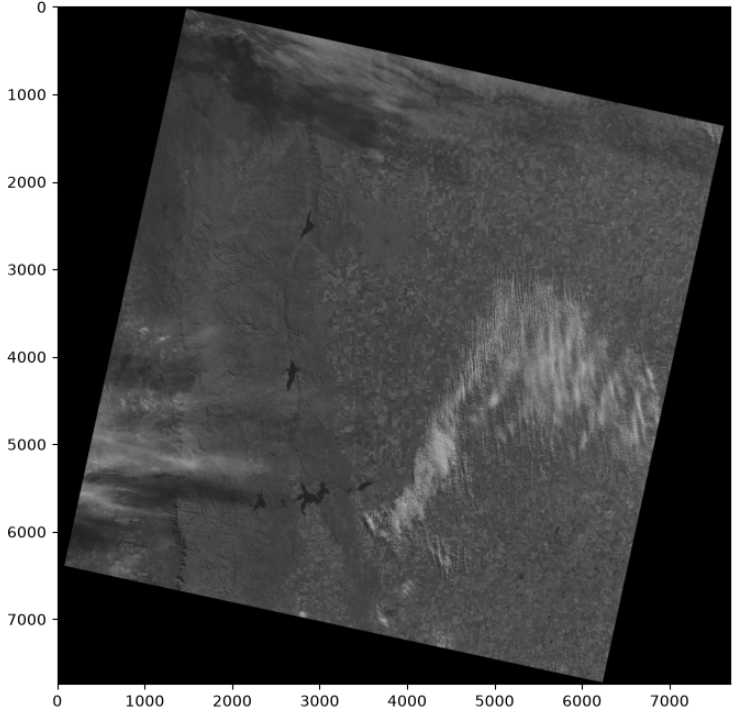

Abrí esa banda saelital con Python, identificá cuál es el valor de `nodata`, y usalo en la función `scale` para visualizar la banda con mejor contraste.

<h3 style="color:red;">Ejercicio 3.2. - Entregable!</h3>

Sobre la escena del ejercicio anterior, definí una esquina superior izquierda (`ulx,uly`) y una esquina inferior derecha (`lrx,lry`), y extraé el recángulo definido por sus coordenadas replicando el ejercicio 2.1, o utilizando la función `subset_img` del ejercicio 3.4 si ya la tenés implementada. Ploteá el recorte extraído usando `imshow`.

<h3 style="color:red;">Ejercicio 3.3. - Entregable!</h3>

Descargá el siguiente [archivo Geotiff](https://drive.google.com/file/d/1dIuD4Wa-hXH43iz5Fx5NaMi1hxHlwD4U/view?usp=sharing) que contiene un mapa de NDWI realizado a partir de una imagen SPOT. Leelo con `Rasterio`, visualizá los datos (la imagen, el histograma), y determiná un umbral que te ayude a binarizar la imagen y distinguir Agua de No-Agua, aplicando la lógica que utilizamos en la clase 01 sobre la imagen de Homero (la que pasamos a 0-1). Luego, ayudate del `transform` de la imagen para determinar qué superficie tiene cada clase, como en el ejercicio de la sección 2.2.

### Ejercicio 3.4

Defina una función que genere un recorte a partir de unas coordenadas y una imagen suministrada y que además devuelva la ventana utilizada para hacer ese recorte. La función deberá tener la siguiente estructura:

```python
ul_x, ul_y = 389015.794, 6527907.484
lr_x, lr_y = 391265.904, 6525657.498

ds = rasterio.open('data/SPOT_20170806_PAN.tif')


def subset_img(ds, ulx, uly, lrx, lry):
    '''
    Descripción de la función
    '''

    # código....

    return subset, window

subset, window = subset_img(ds, ul_x, ul_y, lr_x, lr_y)

fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(subset[0], cmap='Greys_r')
ax.set_title('Subset')
plt.show()
```

Respecto a la variable `window` que debe retornar la función, debe definirse intermanente como `Window(col_off, row_off, width, height)`. En la próxima clase este dato nos será de gran ayuda.

Guardar la función junto a `scale`en el archivo funciones.py.